# Single Topic RAG Evaluation Notebook

This notebook evaluates the RAG system's performance on **single-document question answering**.

## Evaluation Methodology

The evaluation tests three distinct question types:

1. **Single Passage Questions** - Answers can be found in a single document chunk (tests basic retrieval and comprehension)
2. **Multi Passage Questions** - Answers require synthesizing information from multiple chunks (tests information aggregation)
3. **No Answer Questions** - Questions that cannot be answered from the document (tests hallucination prevention)

## Scoring

Uses an **LLM-as-judge** approach with 0-5 scoring scale:
- Questions are evaluated by comparing generated answers against reference answers
- Provides both quantitative scores and qualitative feedback

## Dataset

- 20 diverse documents from various domains (gaming wikis, technical docs, academic papers, fiction, etc.)
- Document sizes range from 2 to 117 pages
- Each document is chunked and stored in isolated vector store collections

In [ ]:
import json
import os
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from dotenv import load_dotenv, find_dotenv

from doc_chat.evaluation.rag_judge_agent import evaluate_response
from doc_chat.llm import create_llm
from doc_chat.rag.citation_retrieval_chain import CitationRetrievalChain
from doc_chat.rag.document_loader import DocumentLoader
from doc_chat.rag.weaviate_vector_store import WeaviateVectorStore
from doc_chat.models import Document, DocumentChunk

_ = load_dotenv(find_dotenv())

## 1. Load Document Metadata

Load the CSV file containing metadata for all 20 evaluation documents including:


In [2]:
input_dir = '../../data/single_topic_rag_evaluation_dataset/processed'
documents_file = os.path.join(input_dir, 'documents_processed_2.csv')
pd_documents = pd.read_csv(documents_file)
pd_documents

,index,source_url,text,num_pages,total_word_count,avg_words_per_page,total_char_count,avg_chars_per_page
0,0,https://enterthegungeon.fandom.com/wiki/Bullet...,Bullet Kin\nBullet Kin are one of the most com...,7,1847.0,263.0,10609.0,1515.0
1,1,https://www.dropbox.com/scl/fi/ljtdg6eaucrbf1a...,---The Paths through the Underground/Underdark...,2,470.0,235.0,2737.0,1368.0
2,2,https://bytes-and-nibbles.web.app/bytes/stici-...,Semantic and Textual Inference Chatbot Interfa...,11,3786.0,344.0,22113.0,2010.0
3,3,https://github.com/llmware-ai/llmware,llmware\n\nBuilding Enterprise RAG Pipelines w...,13,3007.0,231.0,20333.0,1564.0
4,4,https://docs.marimo.io/recipes.html,Recipes\nThis page includes code snippets or “...,11,1797.0,163.0,11257.0,1023.0
5,5,https://towardsdatascience.com/how-to-maximize...,How to Maximize Your Impact as a Data Scientis...,8,2446.0,305.0,14217.0,1777.0
6,6,https://ec.europa.eu/commission/presscorner/de...,Why do we need to regulate the use of Artifici...,18,5399.0,299.0,35372.0,1965.0
7,7,https://bg3.wiki/wiki/The_Emperor,The Emperor is a mind flayer who appears in Ba...,10,2973.0,297.0,17889.0,1788.0
8,8,https://whattocook.substack.com/p/so-into-nort...,so into northern spain!\nour magical urban-plu...,6,2046.0,341.0,11259.0,1876.0
9,9,https://dmtalkies.com/the-zone-of-interest-end...,‘The Zone Of Interest’ Ending Explained & Film...,6,2325.0,387.0,13467.0,2244.0


## 2. Load and Split Documents

Process each PDF document using the `DocumentLoader`:
- Loads the full document text
- Splits into chunks using the default chunking strategy
- Records the number of splits per document for analysis

In [3]:
all_splits = []
for index, row in pd_documents.iterrows():
    doc_path = f"{input_dir}/pdf_2/document_{index}.pdf"
    loader = DocumentLoader(doc_path)
    documents, splits = loader.load_and_split()
    pd_documents.loc[index, 'num_splits'] = int(len(splits))
    all_splits.append(splits)

pd_documents['num_splits'] = pd_documents['num_splits'].astype(int)
pd_documents

,index,source_url,text,num_pages,total_word_count,avg_words_per_page,total_char_count,avg_chars_per_page,num_splits
0,0,https://enterthegungeon.fandom.com/wiki/Bullet...,Bullet Kin\nBullet Kin are one of the most com...,7,1847.0,263.0,10609.0,1515.0,14
1,1,https://www.dropbox.com/scl/fi/ljtdg6eaucrbf1a...,---The Paths through the Underground/Underdark...,2,470.0,235.0,2737.0,1368.0,4
2,2,https://bytes-and-nibbles.web.app/bytes/stici-...,Semantic and Textual Inference Chatbot Interfa...,11,3786.0,344.0,22113.0,2010.0,30
3,3,https://github.com/llmware-ai/llmware,llmware\n\nBuilding Enterprise RAG Pipelines w...,13,3007.0,231.0,20333.0,1564.0,27
4,4,https://docs.marimo.io/recipes.html,Recipes\nThis page includes code snippets or “...,11,1797.0,163.0,11257.0,1023.0,17
5,5,https://towardsdatascience.com/how-to-maximize...,How to Maximize Your Impact as a Data Scientis...,8,2446.0,305.0,14217.0,1777.0,18
6,6,https://ec.europa.eu/commission/presscorner/de...,Why do we need to regulate the use of Artifici...,18,5399.0,299.0,35372.0,1965.0,52
7,7,https://bg3.wiki/wiki/The_Emperor,The Emperor is a mind flayer who appears in Ba...,10,2973.0,297.0,17889.0,1788.0,25
8,8,https://whattocook.substack.com/p/so-into-nort...,so into northern spain!\nour magical urban-plu...,6,2046.0,341.0,11259.0,1876.0,17
9,9,https://dmtalkies.com/the-zone-of-interest-end...,‘The Zone Of Interest’ Ending Explained & Film...,6,2325.0,387.0,13467.0,2244.0,16


## 3. Initialize Vector Store


In [4]:
user_id = 'single_topic_rag_evaluation'
vector_store = await WeaviateVectorStore.create(
    host='localhost',
    port=8080,
    embedding_model='text-embedding-3-small'
)

# Create tenant for this evaluation user
await vector_store.create_tenant(user_id)

## 4. Index Documents


In [5]:
for index, splits in enumerate(all_splits):
    print('indexing document: ', index, 'number of splits: ', len(splits))

    doc_id = f'document_{index}'
    file_name = f'document_{index}.pdf'
    created_at = datetime.now()
    num_pages = pd_documents.loc[index, 'num_pages']

    # Create Document object
    document = Document(
        doc_id=doc_id,
        file_name=file_name,
        created_at=created_at,
        num_pages=int(num_pages)
    )

    # Create DocumentChunk objects from splits
    chunks = []
    for i, split in enumerate(splits):
        chunk = DocumentChunk(
            chunk_id=f'chunk_{i}',
            doc_id=doc_id,
            page_number=split.metadata.get('page', 0),
            page_content=split.page_content,
            created_at=created_at
        )
        chunks.append(chunk)

    # Index the document and its chunks
    await vector_store.index_document(user_id=user_id, document=document, chunks=chunks)

indexing document:  0 number of splits:  14


/Users/patrick/projects/doc-chat/api/venv/lib/python3.13/site-packages/weaviate/warnings.py:256: UserWarning: Con002: You are using the datetime object 2025-11-29 19:50:27.221890 without a timezone. The timezone will be set to UTC.
            To use a different timezone, specify it in the datetime object. For example:
            datetime.datetime(2021, 1, 1, 0, 0, 0, tzinfo=datetime.timezone(-datetime.timedelta(hours=2))).isoformat() = 2021-01-01T00:00:00-02:00
            
  warnings.warn(


indexing document:  1 number of splits:  4


/Users/patrick/projects/doc-chat/api/venv/lib/python3.13/site-packages/weaviate/warnings.py:256: UserWarning: Con002: You are using the datetime object 2025-11-29 19:50:31.022808 without a timezone. The timezone will be set to UTC.
            To use a different timezone, specify it in the datetime object. For example:
            datetime.datetime(2021, 1, 1, 0, 0, 0, tzinfo=datetime.timezone(-datetime.timedelta(hours=2))).isoformat() = 2021-01-01T00:00:00-02:00
            
  warnings.warn(


indexing document:  2 number of splits:  30


...

/Users/patrick/projects/doc-chat/api/venv/lib/python3.13/site-packages/weaviate/warnings.py:256: UserWarning: Con002: You are using the datetime object 2025-11-29 19:50:47.416802 without a timezone. The timezone will be set to UTC.
            To use a different timezone, specify it in the datetime object. For example:
            datetime.datetime(2021, 1, 1, 0, 0, 0, tzinfo=datetime.timezone(-datetime.timedelta(hours=2))).isoformat() = 2021-01-01T00:00:00-02:00
            
  warnings.warn(


indexing document:  18 number of splits:  71


/Users/patrick/projects/doc-chat/api/venv/lib/python3.13/site-packages/weaviate/warnings.py:256: UserWarning: Con002: You are using the datetime object 2025-11-29 19:50:48.356742 without a timezone. The timezone will be set to UTC.
            To use a different timezone, specify it in the datetime object. For example:
            datetime.datetime(2021, 1, 1, 0, 0, 0, tzinfo=datetime.timezone(-datetime.timedelta(hours=2))).isoformat() = 2021-01-01T00:00:00-02:00
            
  warnings.warn(


indexing document:  19 number of splits:  93


/Users/patrick/projects/doc-chat/api/venv/lib/python3.13/site-packages/weaviate/warnings.py:256: UserWarning: Con002: You are using the datetime object 2025-11-29 19:50:49.651118 without a timezone. The timezone will be set to UTC.
            To use a different timezone, specify it in the datetime object. For example:
            datetime.datetime(2021, 1, 1, 0, 0, 0, tzinfo=datetime.timezone(-datetime.timedelta(hours=2))).isoformat() = 2021-01-01T00:00:00-02:00
            
  warnings.warn(


## 5. Initialize Retrieval Chain

Create the `CitationRetrievalChain` for answer generation

In [6]:
# TODO: use vector store as retriever
retrieval_chain = CitationRetrievalChain(retriever=None,
                                         llm=create_llm())

## 6. Define Evaluation Function

The `retrieve_and_answer()` function orchestrates the complete evaluation pipeline:

### Process Flow
For each question in the dataset:
1. **Retrieve** top-k relevant document chunks from the vector store
2. **Generate** an answer using the retrieval chain
3. **Evaluate** the generated answer against the reference answer using LLM-as-judge
4. **Store** results including generated answer, referenced documents, score (0-5), and feedback


In [7]:
async def retrieve_and_answer(data):
    for index, question_row in data.iterrows():
        question = question_row['question']
        reference_answer = question_row.get('answer', "I don't know")
        document_index = question_row['document_index']
        doc_id = f'document_{document_index}'

        print(f'Processing question: {index}, doc_id: {doc_id}')

        # Search for relevant chunks using WeaviateVectorStore
        found_chunks = await vector_store.search_chunks(
            user_id=user_id,
            doc_id=doc_id,
            query=question,
            k=5
        )

        # Convert DocumentChunk objects to format expected by CitationRetrievalChain
        # Create simple document objects with page_content and metadata
        from doc_chat.rag.multi_tenant_vector_store import VectorStoreDocument
        found_documents = [
            VectorStoreDocument(
                id=chunk.chunk_id,
                page_content=chunk.page_content,
                metadata={'page': chunk.page_number, 'created': str(chunk.created_at)}
            )
            for chunk in found_chunks
        ]

        response = retrieval_chain.invoke(query=question, documents=found_documents, include_references_in_answer=False)

        generated_answer = response['answer']

        data.loc[index, 'generated_answer'] = generated_answer
        data.loc[index, 'referenced_documents'] = json.dumps(response['referenced_documents'])

        eval_result = evaluate_response(
            instruction=question,
            reference_answer=reference_answer,
            generated_answer=generated_answer
        )

        data.loc[index, 'score'] = eval_result.score
        data.loc[index, 'feedback'] = eval_result.feedback

    return data


## 7. Run Evaluation

Generate and evaluate answers for all three question types:

### Question Types
- **Single Passage**: Tests basic retrieval and comprehension
- **Multi Passage**: Tests ability to synthesize information across multiple chunks  
- **No Answer**: Tests hallucination prevention (system should respond "I don't know")

Results are saved to CSV files for later analysis.

In [8]:
results_directory = '../../data/single_topic_rag_evaluation_dataset/results_4'
if not os.path.exists(results_directory):
    os.makedirs(results_directory)

In [9]:
pd_documents.to_csv(f'{results_directory}/documents_predict.csv', index=False)

pd_single_passage = pd.read_csv(f'{input_dir}/single_passage_answer_questions.csv')
pd_single_passage_result = await retrieve_and_answer(pd_single_passage)
pd_single_passage_result.to_csv(f'{results_directory}/single_passage_answer_questions_predict.csv', index=False)

pd_multi_passage = pd.read_csv(f'{input_dir}/multi_passage_answer_questions.csv')
pd_multi_passage_result = await retrieve_and_answer(pd_multi_passage)
pd_multi_passage_result.to_csv(f'{results_directory}/multi_passage_answer_questions_predict.csv', index=False)

pd_no_answer = pd.read_csv(f'{input_dir}/no_answer_questions.csv')
pd_no_answer_result = await retrieve_and_answer(pd_no_answer)
pd_no_answer_result.to_csv(f'{results_directory}/no_answer_questions_predict.csv', index=False)

Processing question: 0, doc_id: document_0
Processing question: 1, doc_id: document_0
Processing question: 2, doc_id: document_1
Processing question: 3, doc_id: document_1
Processing question: 4, doc_id: document_2
Processing question: 5, doc_id: document_2
Processing question: 6, doc_id: document_3
Processing question: 7, doc_id: document_3
Processing question: 8, doc_id: document_4
Processing question: 9, doc_id: document_4
Processing question: 10, doc_id: document_5
Processing question: 11, doc_id: document_5
Processing question: 12, doc_id: document_6
Processing question: 13, doc_id: document_6
Processing question: 14, doc_id: document_7
Processing question: 15, doc_id: document_7
Processing question: 16, doc_id: document_8
Processing question: 17, doc_id: document_8
Processing question: 18, doc_id: document_9
Processing question: 19, doc_id: document_9
Processing question: 20, doc_id: document_10
Processing question: 21, doc_id: document_10
Processing question: 22, doc_id: documen

## 8. Compare Results Across Runs

Analyze and visualize results from multiple evaluation runs to track performance changes.

### Metrics
- **Accuracy**: Normalized score (0-1 scale) = `sum(scores) / (num_questions * 5)`
- **Mean**: Average score across all questions
- **Median**: Median score

### Visualizations
Bar charts comparing accuracy across different runs for each question type.


Evaluating results...
Single Passage Accuracy: 0.65
Multi Passage Accuracy: 0.53
No Answer Accuracy: 0.93

Evaluating results_2...
Single Passage Accuracy: 0.66
Multi Passage Accuracy: 0.52
No Answer Accuracy: 0.93

Evaluating results_3...
Single Passage Accuracy: 0.71
Multi Passage Accuracy: 0.60
No Answer Accuracy: 0.94

Evaluating results_4...
Single Passage Accuracy: 0.66
Multi Passage Accuracy: 0.53
No Answer Accuracy: 0.92


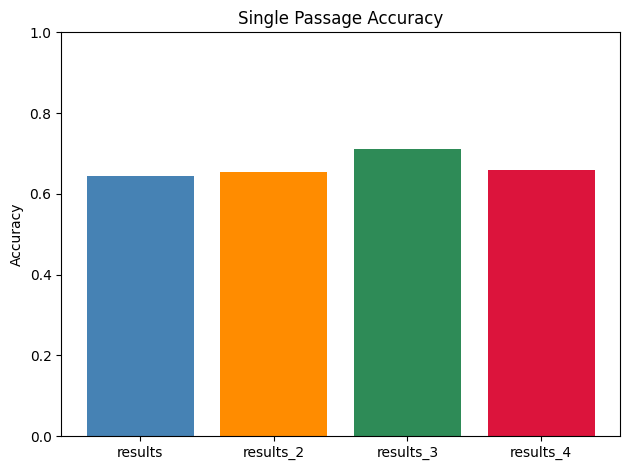

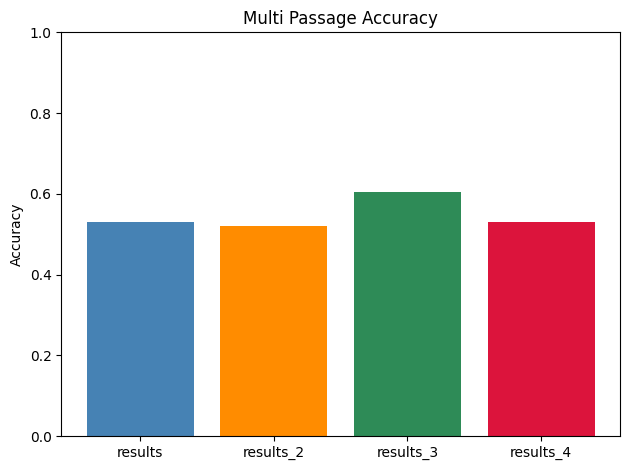

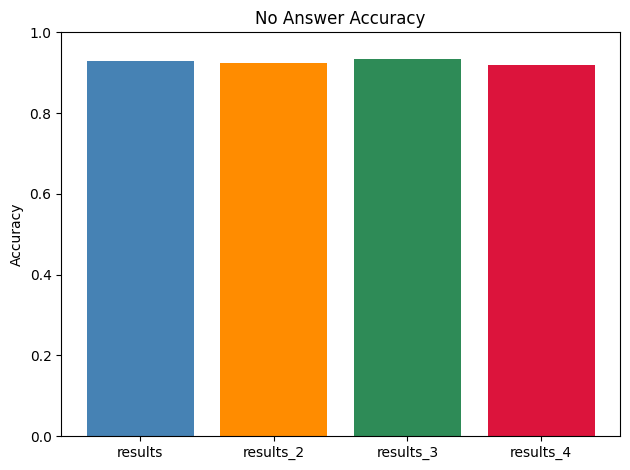

In [10]:
result_set = ["results", "results_2", "results_3", "results_4"]


def summary(pd_result):
    total_questions = len(pd_result)
    score_sum = pd_result['score'].sum()
    accuracy = score_sum / (total_questions * 5)
    mean = pd_result['score'].mean()
    median = pd_result['score'].median()
    return {'accuracy': accuracy, 'mean': mean, 'median': median}


def print_config(config_path):
    with open(config_path, 'r') as f:
        config = yaml.safe_load(f)
    print("Evaluation Parameters:")
    print(yaml.dump(config, default_flow_style=False, sort_keys=False))


single_passage_accuracies = []
multi_passage_accuracies = []
no_answer_accuracies = []

for result in result_set:
    results_directory = f"../../data/single_topic_rag_evaluation_dataset/{result}"
    print(f'\nEvaluating {result}...')

    pd_single_passage_result = pd.read_csv(f'{results_directory}/single_passage_answer_questions_predict.csv')
    single_passage_summary = summary(pd_single_passage_result)

    pd_multi_passage_result = pd.read_csv(f'{results_directory}/multi_passage_answer_questions_predict.csv')
    multi_passage_summary = summary(pd_multi_passage_result)

    pd_no_answer_result = pd.read_csv(f'{results_directory}/no_answer_questions_predict.csv')
    no_answer_summary = summary(pd_no_answer_result)

    single_passage_accuracies.append(single_passage_summary['accuracy'])
    multi_passage_accuracies.append(multi_passage_summary['accuracy'])
    no_answer_accuracies.append(no_answer_summary['accuracy'])

    print(f"Single Passage Accuracy: {single_passage_summary['accuracy']:.2f}")
    print(f"Multi Passage Accuracy: {multi_passage_summary['accuracy']:.2f}")
    print(f"No Answer Accuracy: {no_answer_summary['accuracy']:.2f}")
    #print_config(f'{results_directory}/config.yaml')

x = np.arange(len(result_set))
color_palette = ['steelblue', 'darkorange', 'seagreen', 'crimson', 'goldenrod', 'purple']


def plot_accuracies(data, title):
    plt.figure()
    plt.bar(x, data, color=color_palette, tick_label=result_set)
    plt.ylim(0, 1)
    plt.ylabel('Accuracy')
    plt.title(title)
    plt.tight_layout()
    plt.show()


plot_accuracies(single_passage_accuracies, 'Single Passage Accuracy')
plot_accuracies(multi_passage_accuracies, 'Multi Passage Accuracy')
plot_accuracies(no_answer_accuracies, 'No Answer Accuracy')